<center><h1>Chong_Xie_HW2</h1></center>
<br>
<br>

Name: Chong Xie
<br>
USC ID: 6800668300

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import itertools
import statsmodels.api as sm

Get the Cycle Power Plant Data Set

In [51]:
import pandas as pd

df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')

### (b) Exploring the data

#### i. rows and columns

In [52]:
display(df.head(5))
print(df.shape)
print('There are {} rows and {} columns in the dataset.'.format(df.shape[0], df.shape[1]))

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


(9568, 5)
There are 9568 rows and 5 columns in the dataset.


There are 9568 rows and 5 columns in the dataset. The rows represent data points of the power plant that contain hourly average ambient variables Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP, PE in this dataset). The columns represent the features above.

#### ii. pairwise scatterplots of all the varianbles

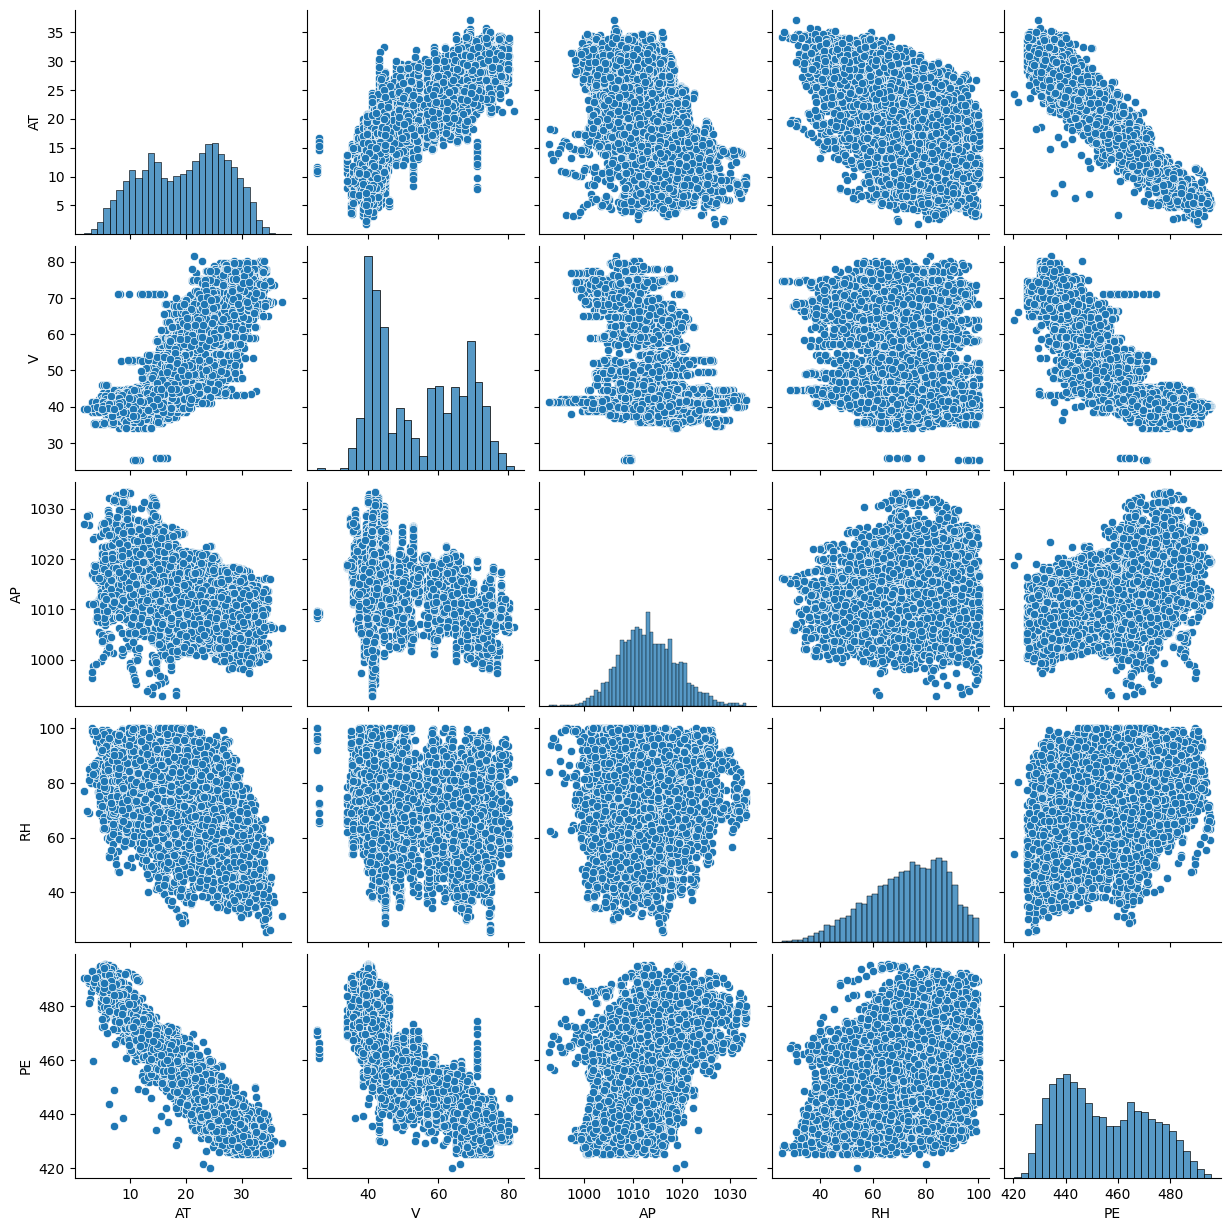

In [53]:
sns.pairplot(data=df)
plt.show()

From the plots, I found that:
- AT and V have strong negative relation with PE.
- AT has a positive relation with V.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [54]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


### (c) Simple Linear Regression

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ AT
Intercept: 497.0341
Slope: -2.1713
R^2: 0.8989
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


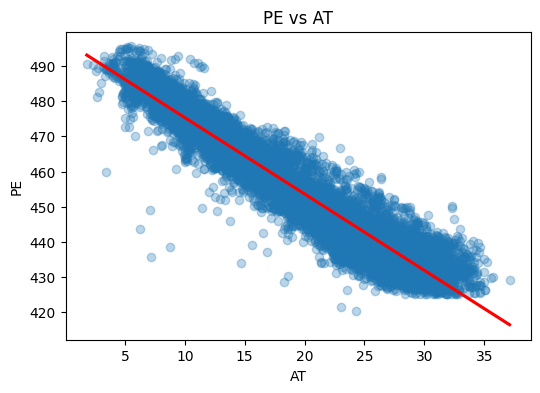

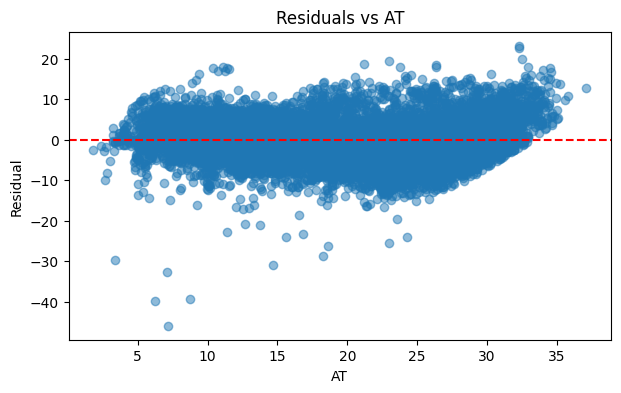

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ V
Intercept: 517.8015
Slope: -1.1681
R^2: 0.7565
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


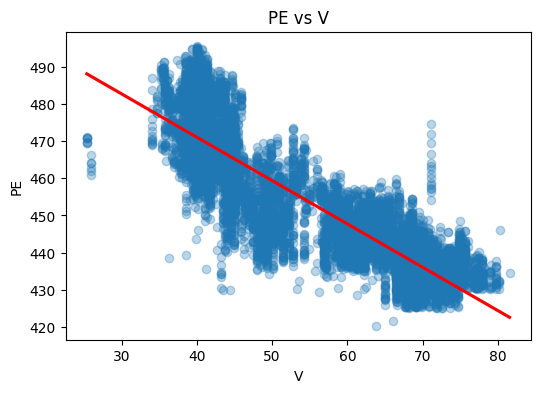

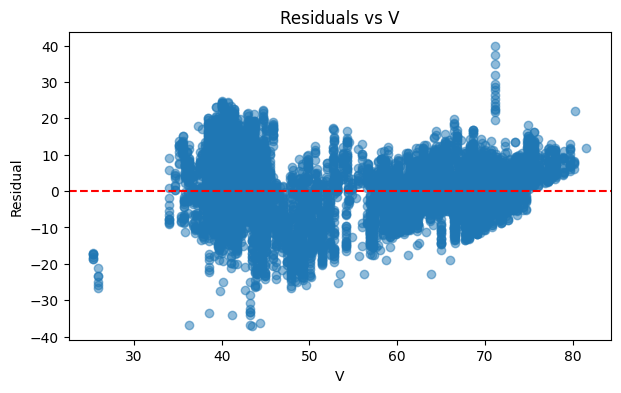

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ AP
Intercept: -1055.2610
Slope: 1.4899
R^2: 0.2688
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


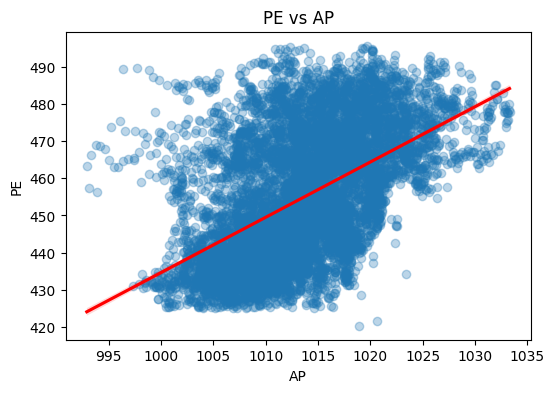

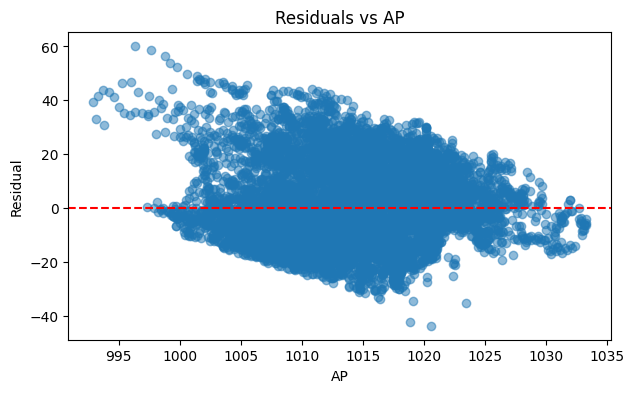

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ RH
Intercept: 420.9618
Slope: 0.4557
R^2: 0.1519
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


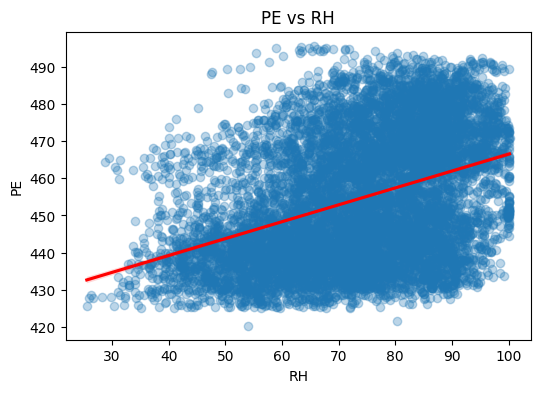

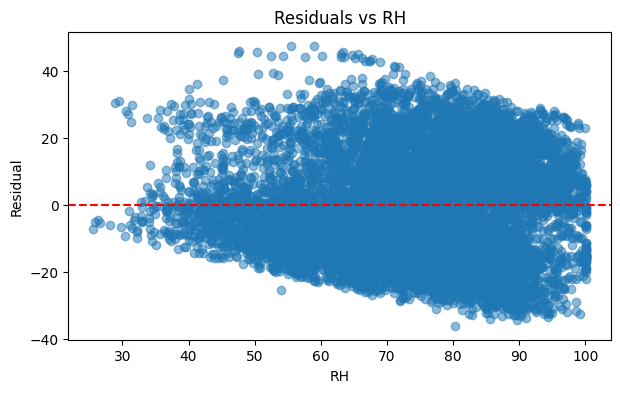

In [55]:
resp = 'PE'
simple_lr_parameters = []

for predictor in ['AT', 'V', 'AP', 'RH']:
    X = df[predictor]
    y = df[resp]
    
    # add constant for the beta0 constant in the linear regression model
    model = sm.OLS(y, sm.add_constant(X)).fit()
    residuals = model.resid

    simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))

    print(f"Model: {resp} ~ {predictor}")
    print(f"Intercept: {model.params['const']:.4f}")
    print(f"Slope: {model.params[1]:.4f}")
    print(f"R^2: {model.rsquared:.4f}")
    print(f"p-value for slope: {model.pvalues[predictor]:.5e}")
    
    if model.pvalues[predictor] < 0.05:
        print("Conclusion: statistically significant association")
    else:
        print("Conclusion: not statistically significant")
    
    # scatter plot + fitted line
    plt.figure(figsize=(6, 4))
    sns.regplot(x=df[predictor], y=df[resp], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f"{resp} vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(resp)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(df[predictor], residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residuals vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel("Residual")
    plt.show()

Residuals:

- AT (Temperatures): There are a few outliers in the lower-left of the graph, between 5 and 10.
- V (Exhaust Vaccum): There are some outliers in the lower-left and upper-right of the graph.
- AP (Ambient Pressure): There are some outliers in the upper-left of the graph.
- RH (Relative Humidity): On both right and left side of the graph, there are outliers.

### (d) Multiple Regression

In [56]:
X = df[['AT', 'V', 'AP', 'RH']]
model = sm.OLS(df[resp], sm.add_constant(X)).fit()
multi_parameters = model.params[1:]
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:30:37   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Observation:

For all the predictors, we **can** reject the null hypothesis $H_0: \beta_j = 0$ as the p values are 0 (less than 0.05)

### (e) 1c Compare to 1d

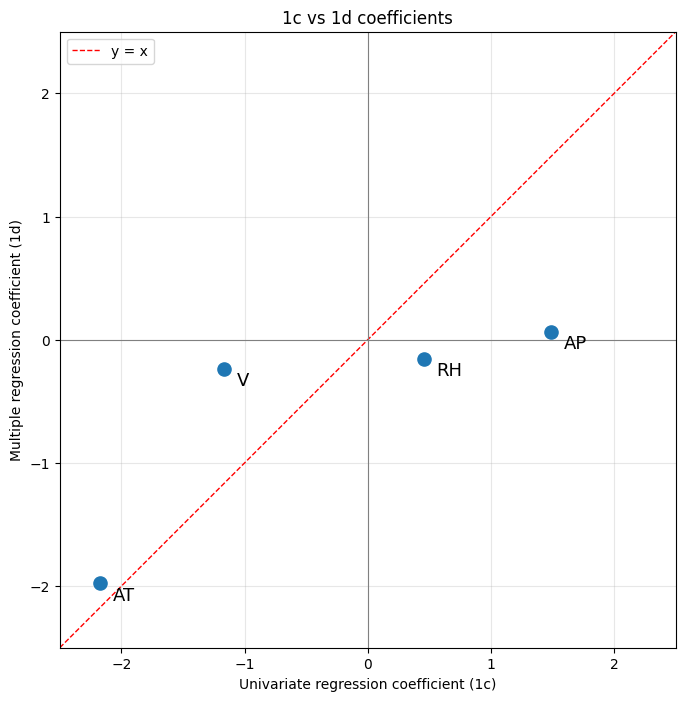

In [57]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, _, slope, _, _ in simple_lr_parameters:
    ax.scatter(slope, multi_parameters[name], s=90, color='tab:blue', zorder=3)
    ax.annotate(name, (slope, multi_parameters[name]),
                textcoords='offset points', xytext=(9, -12), fontsize=13)

lim = [-2.5, 2.5]
ax.plot(lim, lim, 'r--', lw=1, label='y = x')
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)

ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Univariate regression coefficient (1c)')
ax.set_ylabel('Multiple regression coefficient (1d)')
ax.set_title('1c vs 1d coefficients')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

Observations:
- For AT, the univariate coeff is close to the multi coeff.
- For V, the multi coeff is higher than univariate coeff.
- For RH and AP, the multi coeff is lower than univariate coeff.

### (f) Nonlinear Association

Model: PE ~ AT + AT^2 + AT^3
R^2: 0.9119 (linear: 0.8989)
p-value for X^2: 8.83305e-73
p-value for X^3: 3.65218e-110
Conclusion: evidence of nonlinear association


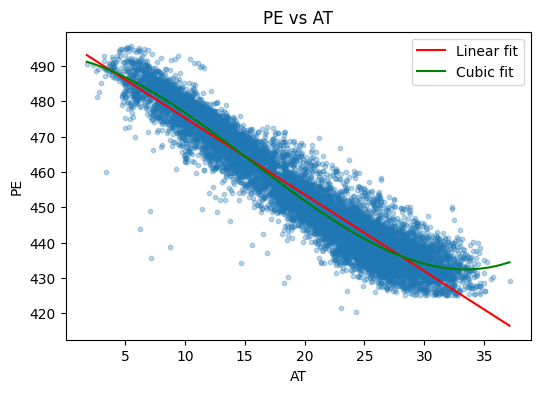

Model: PE ~ V + V^2 + V^3
R^2: 0.7750 (linear: 0.7565)
p-value for X^2: 7.68497e-01
p-value for X^3: 1.37349e-02
Conclusion: evidence of nonlinear association


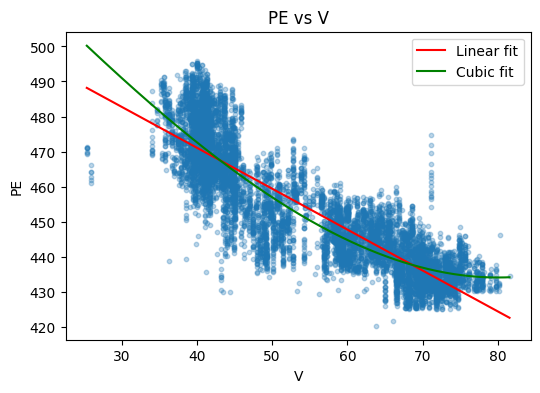

Model: PE ~ AP + AP^2 + AP^3
R^2: 0.2749 (linear: 0.2688)
p-value for X^2: 3.66670e-17
p-value for X^3: 8.26415e-18
Conclusion: evidence of nonlinear association


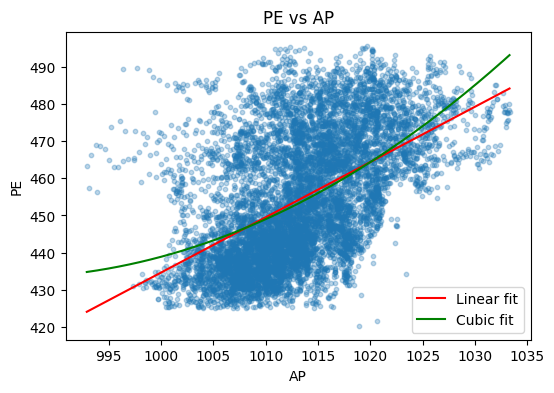

Model: PE ~ RH + RH^2 + RH^3
R^2: 0.1537 (linear: 0.1519)
p-value for X^2: 9.39543e-06
p-value for X^3: 1.44028e-05
Conclusion: evidence of nonlinear association


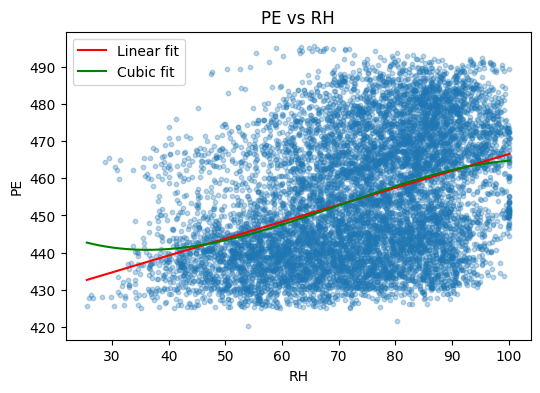

In [58]:
resp = 'PE'
nonlinear_parameters = []

for predictor in ['AT', 'V', 'AP', 'RH']:
    X = pd.DataFrame({
        'X':  df[predictor],
        'X2': df[predictor] ** 2,
        'X3': df[predictor] ** 3
    })
    y = df[resp]

    model = sm.OLS(y, sm.add_constant(X)).fit()
    linear_model = sm.OLS(y, sm.add_constant(df[[predictor]])).fit()

    nonlinear_parameters.append((predictor, linear_model.rsquared, model.rsquared,
                                 model.pvalues['X2'], model.pvalues['X3']))

    print(f"Model: {resp} ~ {predictor} + {predictor}^2 + {predictor}^3")
    print(f"R^2: {model.rsquared:.4f} (linear: {linear_model.rsquared:.4f})")
    print(f"p-value for X^2: {model.pvalues['X2']:.5e}")
    print(f"p-value for X^3: {model.pvalues['X3']:.5e}")

    if model.pvalues['X2'] < 0.05 or model.pvalues['X3'] < 0.05:
        print("Conclusion: evidence of nonlinear association")
    else:
        print("Conclusion: no evidence of nonlinear association")

    # scatter plot + linear fit vs cubic fit
    x_grid = np.linspace(df[predictor].min(), df[predictor].max(), 200)
    grid = sm.add_constant(pd.DataFrame({'X': x_grid, 'X2': x_grid ** 2, 'X3': x_grid ** 3}))
    cubic_line  = model.predict(grid)
    linear_line = linear_model.predict(sm.add_constant(pd.DataFrame({predictor: x_grid})))

    plt.figure(figsize=(6, 4))
    plt.scatter(df[predictor], df[resp], alpha=0.3, s=10)
    plt.plot(x_grid, linear_line, color='red', label='Linear fit')
    plt.plot(x_grid, cubic_line, color='green', label='Cubic fit')
    plt.title(f"{resp} vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(resp)
    plt.legend()
    plt.show()

### (g) Interactions of Predictors

In [59]:
X = df[["AT", "V", "AP", "RH"]]
poly = sklearn.preprocessing.PolynomialFeatures(interaction_only=True)
X_poly = pd.DataFrame(
    poly.fit_transform(X),
    columns=poly.get_feature_names_out(X.columns),
    index=X.index
)
y = df[resp]

mod = sm.OLS(y, X_poly)
res = mod.fit()
    
# Display model summary
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:30:37   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1            685.7825     78.640      8.721      0.0

In [60]:
poly.get_feature_names_out()

array(['1', 'AT', 'V', 'AP', 'RH', 'AT V', 'AT AP', 'AT RH', 'V AP',
       'V RH', 'AP RH'], dtype=object)

Observations:
Here AT V / AT RH / V AP / AP RH are the interaction terms that are statistically significant.

### (h) Improvement

In [61]:
preds = ['AT', 'V', 'AP', 'RH']
resp = 'PE'
poly = sklearn.preprocessing.PolynomialFeatures(2)

summarize_test_error = {}

train_set, test_set = sklearn.model_selection.train_test_split(df, train_size=0.7)
X_train, Y_train = train_set[preds], train_set[["PE"]]
X_test,  Y_test  = test_set[preds],  test_set[["PE"]]

In [62]:
# Model A: main effects only
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
regr_res = sm.OLS(Y_train, X_train_sm).fit()

regr_train_mse = sklearn.metrics.mean_squared_error(Y_train, regr_res.predict(X_train_sm))
regr_test_mse  = sklearn.metrics.mean_squared_error(Y_test,  regr_res.predict(X_test_sm))
summarize_test_error['Linear Regression without interaction'] = regr_test_mse

# Model B: all interactions + quadratic nonlinearities
Ptr = poly.fit_transform(X_train)
Pte = poly.transform(X_test)
cols = ["const"] + list(poly.get_feature_names_out(preds))[1:]

X_train_poly = pd.DataFrame(Ptr, columns=cols, index=X_train.index)
X_test_poly  = pd.DataFrame(Pte, columns=cols, index=X_test.index)

full_res = sm.OLS(Y_train, X_train_poly).fit()
print(full_res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7287.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:30:37   Log-Likelihood:                -19139.
No. Observations:                6697   AIC:                         3.831e+04
Df Residuals:                    6682   BIC:                         3.841e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8143.1596   1436.500     -5.669      0.0

In [63]:
# Model C: drop insignificant terms by p-value, respecting hierarchy
keep = [c for c in cols if c != "const"]
while True:
    pv = sm.OLS(Y_train, X_train_poly[["const"] + keep]).fit().pvalues
    drop = [c for c in keep
            if pv[c] >= 0.05
            and not (c in preds and any(c in x.split(" ") for x in keep if x not in preds))]
    if not drop:
        break
    keep.remove(max(drop, key=lambda c: pv[c]))

print("Removed terms:", [c for c in cols if c not in keep and c != "const"])

reduce_res = sm.OLS(Y_train, X_train_poly[["const"] + keep]).fit()

reduce_train_mse = sklearn.metrics.mean_squared_error(Y_train, reduce_res.predict(X_train_poly[["const"] + keep]))
reduce_test_mse  = sklearn.metrics.mean_squared_error(Y_test,  reduce_res.predict(X_test_poly[["const"] + keep]))
summarize_test_error['Linear Regression with interaction'] = reduce_test_mse

print("Train MSE for model without interaction is", regr_train_mse)
print("Test  MSE for model without interaction is", regr_test_mse)

print("Train MSE for model with interaction is", reduce_train_mse)
print("Test  MSE for model with interaction is", reduce_test_mse)

Removed terms: ['V^2', 'V AP', 'V RH']
Train MSE for model without interaction is 20.59370108230269
Test  MSE for model without interaction is 21.18264864647968
Train MSE for model with interaction is 17.78008921568646
Test  MSE for model with interaction is 18.936834893017927


From the result above, we see that the model is improved with the interaction terms and quadratic nonlinearities.

### (i) KNN

In [64]:
min_max_scaler = sklearn.preprocessing.MinMaxScaler()
scaling_model = min_max_scaler.fit(X_train)
X_train_scaled = scaling_model.transform(X_train)
X_test_scaled  = scaling_model.transform(X_test)

In [65]:
# With normalized data
k_values = [i for i in range(1, 101)]
k_inv = [1 / k for k in k_values]
train_mse = []
test_mse = []

for k in k_values:
    knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    train_mse.append(sklearn.metrics.mean_squared_error(Y_train, knn.predict(X_train_scaled)))
    test_mse.append(sklearn.metrics.mean_squared_error(Y_test,  knn.predict(X_test_scaled)))

Minimum train MSE with normalized features: 0.0
Optimal k* for training is 1
Minimum test MSE with normalized features: 15.432229886992527
Optimal k* for testing is 6


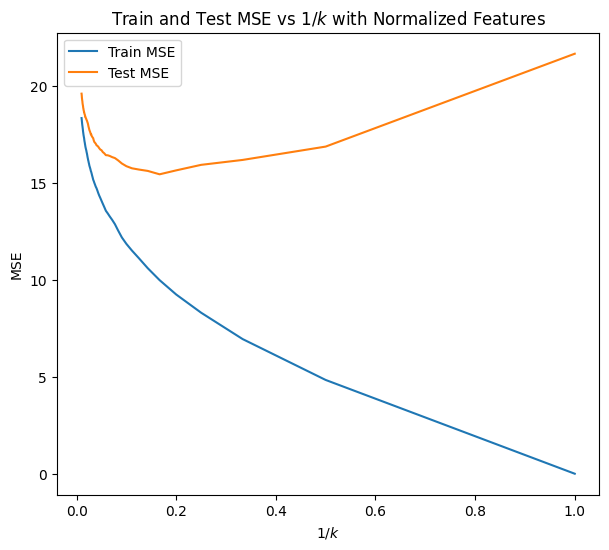

In [66]:
print('Minimum train MSE with normalized features:', min(train_mse))
print('Optimal k* for training is', k_values[np.argmin(train_mse)])
print('Minimum test MSE with normalized features:', min(test_mse))
print('Optimal k* for testing is', k_values[np.argmin(test_mse)])

# Store test MSE
summarize_test_error['KNN Regression with Normalized Features'] = min(test_mse)

plt.figure(figsize=(7, 6))
plt.plot(k_inv, train_mse, label='Train MSE')
plt.plot(k_inv, test_mse, label='Test MSE')
plt.title('Train and Test MSE vs $1/k$ with Normalized Features')
plt.xlabel('$1/k$')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [67]:
# With raw data
train_mse = []
test_mse = []

for k in k_values:
    knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    
    train_mse.append(sklearn.metrics.mean_squared_error(Y_train, knn.predict(X_train)))
    test_mse.append(sklearn.metrics.mean_squared_error(Y_test,  knn.predict(X_test)))

Minimum train MSE with raw data: 0.0
Optimal k* for training is 1
Minimum test MSE with raw data: 16.891839869963995
Optimal k* for testing is 6


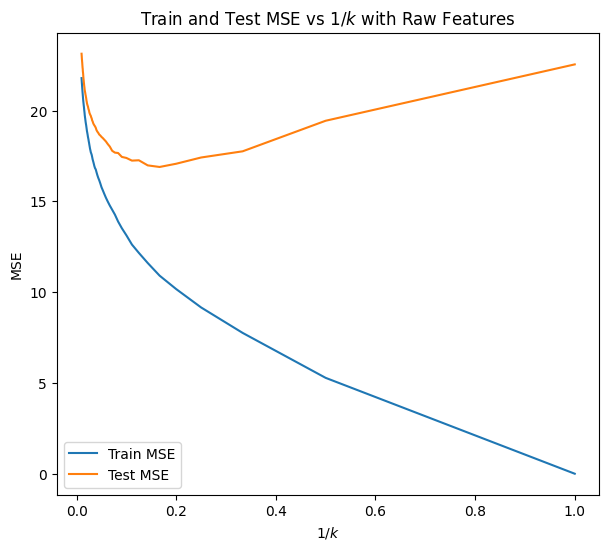

In [68]:
print('Minimum train MSE with raw data:', min(train_mse))
print('Optimal k* for training is', k_values[np.argmin(train_mse)])
print('Minimum test MSE with raw data:', min(test_mse))
print('Optimal k* for testing is', k_values[np.argmin(test_mse)])

# Store test MSE
summarize_test_error['KNN Regression with Raw Data'] = min(test_mse)

plt.figure(figsize=(7, 6))
plt.plot(k_inv, train_mse, label='Train MSE')
plt.plot(k_inv, test_mse, label='Test MSE')
plt.title('Train and Test MSE vs $1/k$ with Raw Features')
plt.xlabel('$1/k$')
plt.ylabel('MSE')
plt.legend()
plt.show()

From above, we found the k* = 6.

### (j ) Compare KNN and Linear

In [69]:
table = pd.DataFrame(summarize_test_error.items(), columns= ['Model Name', 'Test Error'])
display(table)

,Model Name,Test Error
0,Linear Regression without interaction,21.182649
1,Linear Regression with interaction,18.936835
2,KNN Regression with Normalized Features,15.432230
3,KNN Regression with Raw Data,16.891840


Analysis:

From the above, we found out that KNN Regression with Normalized Features has the least error. Also, KNN generally has better performance than linear models.

KNN outperforms linear regression because parts (f) and (g) showed significant nonlinear and interaction effects, which a linear model cannot represent, while KNN is non-parametric and captures such structure locally. Normalization helps because KNN relies on Euclidean distance: the raw predictors have different ranges, so without scaling the distance is dominated by the widest-ranging variables.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

The performance would be better. That's because adequate sample size can help to fit complex data patterns, and the small number of predictors will make the model less likely to overfit.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

The performance would be worse. That's because the large number of predictors will make the model more likely to capture the noise in the data, causing overfitting.

### (c) The relationship between the predictors and response is highly non-linear.

The performance would be better. For inflexible models, fitting the non-linear data would cause large bias. Only the flexible models can fit the non-linearity.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

The performance would be worse. For high variance data, the noise is too large, and the flexible models are more likely to capture the noise points.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

### (b) What is our prediction with K = 1? Why?

### (c) What is our prediction with K = 3? Why?

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?